1. Defining hyperparameters.

In [ ]:
config = {
    #Reproducibility and data.
    "data": {
        "raw_path": "raw/Stars.csv",         
        "test_size": 0.2, #20% of data for testing.               
        "random_state": 42, #Seed fixation for reproducibility.            
        "target_col": "Type", #Target variable.                
        "missing_threshold": 0.5, #Discard columns with more than 50% missing values.     
        "imputation_strategy": "mean" #Filling technique.  
    },
    "model": {
        "hidden_sizes": [32, 16], #Two hidden layers: the firs with 32 neurons, and the second with 16.      
        "dropout": 0.2, #Random shutdown of 20% of neurons.               
        "learning_rate": 0.001, #How much the model weights change in response to the estimated error with each update.       
        "batch_size": 32, #Processing 32 samples at a time before updating their internal weights.              
        "epochs": 100, #Maximum limit of 100 complete passes through the dataset during training.                 
        "early_stopping_patience": 10 #Discontinue training if the loss of validation does not improve for 10 consecutive seasons.  
    }
}

2. Defining seed.

In [ ]:
import wandb
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn. preprocessing import StandardScaler
from sklearn. impute import SimpleImputer
from scipy.stats import ks_2samp, chi2_contingency
import yaml, random, matplotlib.pyplot as plt
import kagglehub, shutil, os

#Set a global seed to ensure reproducibility of experiments.
def set_seed(seed=42):
    #Set seed for Python's built-in random module.
    random.seed (seed)
    #Set seed for NumPy operations.
    np.random.seed(seed)
    #Set seed for PyTorch (CPU).
    torch.manual_seed(seed)
    #If GPU is available, set seed for CUDA as well.
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
set_seed(42)

3. Saving data as a wandb artifact.

In [ ]:
df_raw = pd.read_csv("raw/Stars.csv") #Reading data.

In [ ]:
import wandb

#Initialize a W&B run.
wandb.init(
    project="mlops-star-type",
    job_type="load_raw",   #Defines the pipeline step.
    name="load_raw"        #Name of the run.
)

#Create a dataset artifact.
artifact = wandb.Artifact(
    name="raw_data", 
    type="dataset", 
    description="Star type classification raw dataset from Kaggle"
)

#Save DataFrame temporarily. 
temp_path = "temp_raw.csv"

#Export raw DataFrame to CSV.
df_raw.to_csv(temp_path, index=False)

#Add file to artifact.
artifact.add_file(temp_path)

#Log artifact to W&B.
wandb.log_artifact(artifact)

#Log metadata to W&B dashboard.
wandb.summary["rows"] = len(df_raw)                #Number of rows.
wandb.summary["columns"] = list(df_raw.columns)   #Column names.

#Finish run.
wandb.finish()

print("Raw data artifact saved to W&B.")


rows,240


Raw data artifact saved to W&B.


Cleaning data


In [ ]:
#Remove duplicate rows from a DataFrame.
def remove_duplicates(df:pd.DataFrame)->pd.DataFrame:
    #Store initial number of rows.
    before = len(df)
    
    #Remove duplicate rows.
    df = df.drop_duplicates()

    #Calculate how many rows were removed.
    removed = before - len(df)

    #Print summary of the operation.
    print(
        f"Removed {removed} duplicate rows "
        f"({removed / before:.1%} of dataset)"
    )

    #Logs how many rows were removed and their proportion relative to the original dataset.
    return df


#Apply function to raw dataset.
df_clean = remove_duplicates(df_raw)

 Removed 0 duplicate rows (0.0% of dataset )


In [60]:
def handle_missing_values(df:pd.DataFrame,
    strategy: str = "mean",
    threshold: float = 0.5)->pd.DataFrame:
    missing_fraction=df.isnull().mean()
    cols_to_drop=missing_fraction[
    missing_fraction>threshold
    ].index.tolist()
    df=df.drop(columns=cols_to_drop)
    print (f"Dropped columns (>{ threshold :.0%} missing): {cols_to_drop }")
    numeric_cols=df.select_dtypes(include=[np.number]).columns
    imputer=SimpleImputer(strategy=strategy)
    df[numeric_cols]=imputer.fit_transform(df[numeric_cols])
    cat_cols=df.select_dtypes(include=["object"]).columns
    df[cat_cols]=df[cat_cols].fillna("missing")
    return df
df_clean=handle_missing_values(
    df_clean,
    strategy=config["data"]["imputation_strategy"],
    threshold=config["data"]["missing_threshold"]
)
print(f"Clean dataset: {len(df_clean)} rows, {df_clean.shape[1]} columns")

Dropped columns (>50% missing): []
Clean dataset: 240 rows, 7 columns


C:\Users\Cliente\AppData\Local\Temp\ipykernel_7580\2662225601.py:13: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols=df.select_dtypes(include=["object"]).columns


In [ ]:
df_clean['Color'] = df_clean['Color'].str.lower().str.strip()
df_clean['Color'] = df_clean['Color'].replace({
    'yellow-white': 'white-yellow',
    'yellowish white': 'white-yellow',
    'blue white': 'blue-white',
    'whitish': 'white'
})
df_clean = pd.get_dummies(df_clean, columns=['Color', 'Spectral_Class'], drop_first=True)

print(f"Novas colunas após encoding: {df_clean.columns.tolist()}")

Novas colunas após encoding: ['Temperature', 'L', 'R', 'A_M', 'Type', 'Color_blue-white', 'Color_orange', 'Color_orange-red', 'Color_pale yellow orange', 'Color_red', 'Color_white', 'Color_white-yellow', 'Color_yellowish', 'Spectral_Class_B', 'Spectral_Class_F', 'Spectral_Class_G', 'Spectral_Class_K', 'Spectral_Class_M', 'Spectral_Class_O']


In [62]:
wandb.init(
 project="mlops-star-type",
 job_type="clean_data",
 name="clean_data"
 )
artifact=wandb.Artifact(
 "clean_data",
 type ="dataset",
 description="Star type classification after deduplication and imputation"
 )
temp_path= "temp_clean .csv"
df_clean.to_csv(temp_path,index= False)
artifact.add_file(temp_path)
wandb.log_artifact(artifact)

wandb.summary["rows"]=len(df_clean)
wandb.summary["dropped_columns"]=df_clean.shape[1]
wandb.finish()

dropped_columns,19
rows,240


In [63]:
def test_no_missing_values(df:pd.DataFrame)-> None:
    total_missing=df.isnull(). sum ().sum ()
    assert total_missing==0,\
    f"TEST FAILED: {total_missing} missing values remain."
    print ("PASS: no missing values.")
def test_target_values(df:pd.DataFrame,
    target_col: str,
    allowed_values)-> None :
    invalid_mask=~df[target_col].isin(allowed_values)
    invalid_count=invalid_mask. sum ()
    assert invalid_count==0,\
    f"TEST FAILED: { invalid_count } unexpected values in ’{target_col }’:" \
    f"{df.loc[invalid_mask, target_col]. unique ()}"
    print (f"PASS: ’{ target_col }’ contains only valid values.")
test_no_missing_values(df_clean)
print ("All consistency tests passed.")

PASS: no missing values.
All consistency tests passed.


In [65]:
def test_range_checks(df):
    assert df['Type'].between(0, 5).all(), "Erro: 'Type' fora do intervalo [0, 5]"  
    assert (df['Temperature'] > 0).all(), "Erro: Temperatura negativa ou zero detectada"
print("PASS: Valores dentro dos intervalos esperados.")

PASS: Valores dentro dos intervalos esperados.


5


In [66]:
from sklearn.model_selection import train_test_split
import pandas as pd
def split_train_test(df:pd.DataFrame,
    target_col: str ,
    test_size: float = 0.2,
    random_state: int = 42):
    X =df.drop(columns=[target_col])
    y=df[target_col]
    X_train,X_test,y_train,y_test=train_test_split(X,y,
    test_size=test_size,
    random_state=random_state,
    stratify=y
)
    train_df=pd.concat([X_train,y_train],axis=1)
    test_df=pd.concat([X_test,y_test],axis=1)
    return train_df, test_df
train_df,test_df=split_train_test(
    df_clean,
    target_col=config["data"]["target_col"],
    test_size=config["data"]["test_size"],
    random_state=config["data"]["random_state"]
)
print (f" Training set: {len( train_df ):,} rows ")
print (f" Test set : {len (test_df):,} rows ")

 Training set: 192 rows 
 Test set : 48 rows 


In [67]:
from scipy.stats import ks_2samp, chi2_contingency
def compare_distributions(train_df:pd.DataFrame,
    test_df:pd.DataFrame,
    columns: list ) -> dict :
    results={}
    for col in columns:
        train_vals=train_df[col].dropna()
        test_vals=test_df[col].dropna()
        if train_df[col].dtype in ["int64", "float64"]:
            stat,p=ks_2samp(train_vals,test_vals)
            results[col]={"test": "KS", "statistic": stat, "p_value": p}
        else :
            train_counts=train_vals.value_counts(normalize= True )
            test_counts=test_vals.value_counts(normalize= True )
            all_cats= sorted (
            set(train_counts.index).union(test_counts.index))
            train_probs=[train_counts.get(c,0) for c in all_cats]
            test_probs=[test_counts.get(c,0) for c in all_cats]
            chi2,p,_,_=chi2_contingency(
            [train_probs,test_probs])
            results[col]={"test": "Chi2", "statistic": chi2,"p_value": p}
    return results
feature_cols=[c for c in train_df.columns
if c !=config["data"]["target_col"]]
comp_results=compare_distributions(train_df,test_df,feature_cols)

In [68]:
import wandb 
wandb.init(
    project="mlops-star-type",
    job_type="split_data",
    name="split_data"
)
for split_name,split_df in [("train_data", train_df),
    ("test_data", test_df)]:
    path=f"temp_{split_name}.csv"
    split_df.to_csv(path, index=False)
    train_df.to_csv("temp_train_data.csv", index=False)
    test_df.to_csv("temp_test_data.csv", index=False)
    art=wandb.Artifact(split_name, type ="dataset")
    art.add_file(path)
wandb.log_artifact(art)
comp_df=pd.DataFrame(comp_results).T.reset_index()
comp_df.columns=["feature", "test", "statistic", "p_value"]
comp_table=wandb.Table(dataframe=comp_df)
wandb.log({"distribution_comparison": comp_table})
wandb.summary["train_size"] = len(train_df)
wandb.summary["test_size"] = len (test_df)
wandb.finish()
print ("Train and test artifacts saved.")

test_size,48
train_size,192


Train and test artifacts saved.


7

In [69]:
import torch
x = torch.tensor([1.0, 2.0, 3.0])  
A = torch.tensor([[1.0, 2.0],
                  [3.0, 4.0]])    
print(x.shape)   
print(A.shape)   
print(A.dtype)   
W = torch.randn(64, 32)  
b = torch.zeros(32)      
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
W = W.to(device)

torch.Size([3])
torch.Size([2, 2])
torch.float32


In [70]:
import torch.nn as nn
class SimpleLayer(nn.Module):
    def __init__(self , in_features: int , out_features: int):
        super ().__init__()
        self . linear=nn.Linear(in_features,out_features)
        self . relu=nn.ReLU()
    def forward(self , x:torch.Tensor)->torch.Tensor:
        z = self . linear(x) 
        a = self . relu(z) 
        return a
layer=SimpleLayer(10,5)
for name,param in layer.named_parameters():
    print (f"{ name }: { param . shape }")

linear.weight: torch.Size([5, 10])
linear.bias: torch.Size([5])


In [71]:
model=nn.Sequential(
    nn.Linear(10,64), 
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(64,32), 
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(32,1), 
)
print (model)

Sequential(
  (0): Linear(in_features=10, out_features=64, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.2, inplace=False)
  (3): Linear(in_features=64, out_features=32, bias=True)
  (4): ReLU()
  (5): Dropout(p=0.2, inplace=False)
  (6): Linear(in_features=32, out_features=1, bias=True)
)


In [72]:
import torch
from torch.utils.data import TensorDataset, DataLoader
X = torch.randn(1000, 5)
y = torch.randint(0, 2, (1000, 1)).float()
dataset = TensorDataset(X, y)
loader = DataLoader(
    dataset,
    batch_size=32,   
    shuffle=True,    
    num_workers=0    
)
for X_batch, y_batch in loader:
    print(X_batch.shape, y_batch.shape)
    break

torch.Size([32, 5]) torch.Size([32, 1])


8

In [73]:
from sklearn.preprocessing import StandardScaler
from torch.utils.data import TensorDataset,DataLoader
import numpy as np
import torch
def prepare_dataloaders(train_df,test_df,
                        target_col: str ,
                        batch_size: int):
    X_train=train_df.drop(columns=[target_col]).values.astype(np.float32)
    y_train=train_df[target_col].values.astype(np.float32).reshape(-1,1)
    X_test=test_df.drop(columns=[target_col]).values.astype(np.float32)
    y_test=test_df[target_col].values.astype(np.float32).reshape(-1,1)
    scaler=StandardScaler()
    X_train=scaler.fit_transform(X_train)
    X_test=scaler.transform(X_test)
    train_ds=TensorDataset(torch.tensor(X_train),torch.tensor(y_train))
    test_ds=TensorDataset(torch.tensor(X_test),torch.tensor(y_test))
    train_loader=DataLoader(train_ds,batch_size=batch_size,shuffle= True )
    test_loader=DataLoader(test_ds,batch_size=batch_size,shuffle= False )
    return train_loader,test_loader,scaler

In [76]:
import torch.nn as nn
class MLP(nn.Module):
    def __init__(self ,
                input_dim: int ,
                hidden_sizes: list ,
                output_dim: int = 1,
                dropout: float = 0.2):
        super ().__init__()
        layers=[]
        prev_size=input_dim
        for hidden_size in hidden_sizes:
            layers.append(nn.Linear(prev_size,hidden_size))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(p=dropout))
            prev_size=hidden_size
        layers.append(nn.Linear(prev_size,output_dim))
        self .net=nn.Sequential(*layers)
    def forward(self , x:torch.Tensor)->torch.Tensor:
        return self .net(x)
model=MLP(
input_dim=30,
hidden_sizes=[64,32],
dropout=0.2
)
print ( model)
total_params= sum(p.numel() for p in model.parameters())
print (f" Total parameters : { total_params :,}")

MLP(
  (net): Sequential(
    (0): Linear(in_features=30, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)
 Total parameters : 4,097


9

In [77]:
import torch
import torch.nn as nn
import torch.optim as optim
import wandb

def train_model(config, train_loader, test_loader, input_dim):

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model = MLP(
        input_dim=input_dim,
        hidden_sizes=config["model"]["hidden_sizes"],
        dropout=config["model"]["dropout"],
        output_dim=6  # 🔥 número de classes
    ).to(device)

    # 🔥 loss correta pra multiclass
    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        model.parameters(),
        lr=config["model"]["learning_rate"]
    )

    wandb.watch(model, log="all", log_freq=10)

    best_val_loss = float("inf")
    patience = config["model"]["early_stopping_patience"]
    patience_counter = 0

    for epoch in range(config["model"]["epochs"]):

        # 🔹 TRAIN
        model.train()
        train_loss = 0.0

        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device).long().squeeze()  # 🔥 ESSENCIAL

            optimizer.zero_grad()

            output = model(X_batch)  # shape: [batch, 6]
            loss = criterion(output, y_batch)

            loss.backward()
            optimizer.step()

            train_loss += loss.item() * X_batch.size(0)

        train_loss /= len(train_loader.dataset)

        # 🔹 VALIDATION
        model.eval()
        val_loss = 0.0
        correct = 0

        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                X_batch = X_batch.to(device)
                y_batch = y_batch.to(device).long().squeeze()

                output = model(X_batch)
                loss = criterion(output, y_batch)

                val_loss += loss.item() * X_batch.size(0)

                # 🔥 previsão correta multiclass
                pred = torch.argmax(output, dim=1)
                correct += (pred == y_batch).sum().item()

        val_loss /= len(test_loader.dataset)
        val_acc = correct / len(test_loader.dataset)

        # 🔹 LOG
        wandb.log({
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "val_acc": val_acc,
        })

        # 🔹 EARLY STOPPING
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0

            torch.save(model.state_dict(), "best_model.pt")

            model_artifact = wandb.Artifact(
                "trained_model",
                type="model",
                description=f"MLP checkpoint at epoch {epoch}"
            )
            model_artifact.add_file("best_model.pt")
            wandb.log_artifact(model_artifact)

        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch}")
                break

    model.load_state_dict(torch.load("best_model.pt"))
    return model

In [78]:
import pandas as pd
import wandb

wandb.init(
    project="mlops-star-type",
    job_type="train",
    name="mlp_training",
    config=config
)

train_df = pd.read_csv("temp_train_data.csv")
test_df = pd.read_csv("temp_test_data.csv")

train_loader, test_loader, scaler = prepare_dataloaders(
    train_df,
    test_df,
    target_col=config["data"]["target_col"],
    batch_size=config["model"]["batch_size"]
)

input_dim = train_loader.dataset.tensors[0].shape[1]
print(f"Input dimension: {input_dim} features")

model = train_model(config, train_loader, test_loader, input_dim)

wandb.finish()

print("Training complete. Best model saved to W&B.")

Input dimension: 18 features


epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▇▇▇▇▇▇▇█
train_loss,█████▇▇▆▆▆▄▄▃▃▃▂▂▂▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁
val_acc,▁▁▁▂▂▂▃▄▆▆▆▅▅▆▆▇▇▇▆▇▇▇▇▇█▇▇█▇▇█▇▇█▇█████
val_loss,███▇▇▇▆▆▅▅▄▄▄▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁
epoch,99
train_loss,0.16038
val_acc,0.9375
val_loss,0.1606


Training complete. Best model saved to W&B.


[[8 0 0 0 0 0]
 [0 8 0 0 0 0]
 [0 0 8 0 0 0]
 [0 0 0 8 0 0]
 [0 0 0 1 7 0]
 [0 0 0 0 0 8]]


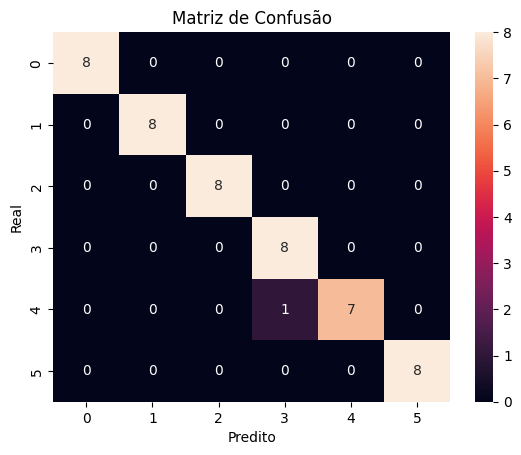

In [79]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        
        outputs = model(X_batch)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()
        
        all_preds.extend(preds)
        all_labels.extend(y_batch.numpy())
cm = confusion_matrix(all_labels, all_preds)
print(cm)
plt.figure()
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predito")
plt.ylabel("Real")
plt.title("Matriz de Confusão")
plt.show()

In [80]:
corr = train_df.corr(numeric_only=True)

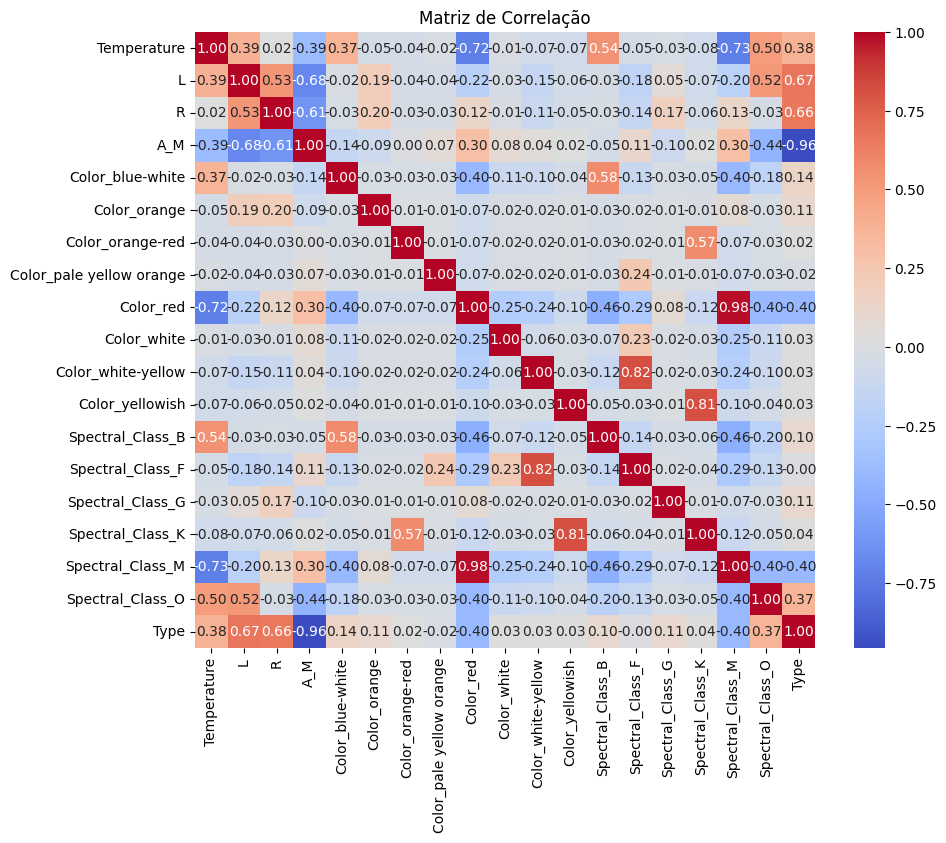

In [81]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de Correlação")
plt.show()

In [82]:
train_df = pd.get_dummies(train_df)
test_df = pd.get_dummies(test_df)
train_df, test_df = train_df.align(test_df, join="left", axis=1, fill_value=0)

In [83]:
from scipy.stats import ks_2samp, chi2_contingency
import pandas as pd
import wandb

# 1. Função Corrigida (Removido o espaço extra em "p_value")
def compare_distributions(train_df: pd.DataFrame,
                          test_df: pd.DataFrame,
                          columns: list) -> dict:
    results = {}
    for col in columns:
        train_vals = train_df[col].dropna()
        test_vals = test_df[col].dropna()
        
        # Teste para variáveis numéricas (Temperatura, Luminosidade, etc.)
        if train_df[col].dtype in ["int64", "float64"]:
            stat, p = ks_2samp(train_vals, test_vals)
            results[col] = {"test": "KS", "statistic": stat, "p_value": p}
        # Teste para variáveis categóricas (Color, Spectral_Class)
        else:
            train_counts = train_vals.value_counts(normalize=True)
            test_counts = test_vals.value_counts(normalize=True)
            all_cats = sorted(set(train_counts.index).union(test_counts.index))
            train_probs = [train_counts.get(c, 0) for c in all_cats]
            test_probs = [test_counts.get(c, 0) for c in all_cats]
            chi2, p, _, _ = chi2_contingency([train_probs, test_probs])
            # Correção do erro de digitação original
            results[col] = {"test": "Chi2", "statistic": chi2, "p_value": p}
    return results

# 2. Identificação das colunas (Excluindo o alvo 'Type')
feature_cols = [c for c in train_df.columns if c != config["data"]["target_col"]]

# 3. Execução da Comparação
comp_results = compare_distributions(train_df, test_df, feature_cols)

# 4. Integração com o Pipeline de MLOps no W&B
wandb.init(
    project="mlops-star-type",
    job_type="split_data",
    name="split_validation"
)

# Transforma os resultados em um DataFrame e renomeia as colunas [2]
comp_df = pd.DataFrame(comp_results).T.reset_index()
comp_df.columns = ["feature", "test", "statistic", "p_value"]

# Loga os resultados como uma tabela interativa no W&B [2]
comp_table = wandb.Table(dataframe=comp_df)
wandb.log({"distribution_comparison": comp_table})

# Registra os tamanhos dos datasets para rastreabilidade [2]
wandb.summary["train_size"] = len(train_df)
wandb.summary["test_size"] = len(test_df)

wandb.finish()

test_size,48
train_size,192
